# SKIN TONE

Analyzing image: 4.jpg
✓ Face detected successfully
✓ Skin color extracted: RGB(np.int64(200), np.int64(151), np.int64(123))
✓ Skin tone classified: Medium (Type IV)


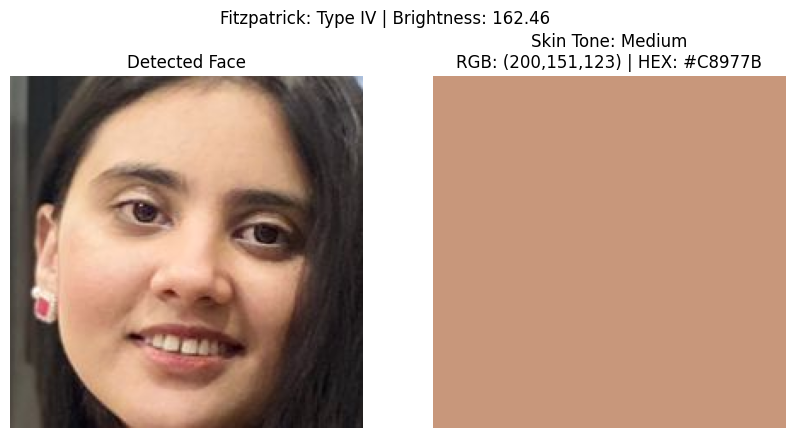


SKIN TONE ANALYSIS RESULTS
Category: Medium
Fitzpatrick Type: Type IV
RGB Color: (200, 151, 123)  |  HEX: #C8977B
Brightness: 162.46

--------------------------------------------------
COLOR RECOMMENDATIONS:
--------------------------------------------------

✓ BEST COLORS FOR YOU:
  • Jewel Tones
  • Teal
  • Purple
  • Ruby Red
  • Golden Yellow
  • Olive Green
  • Magenta
  • Cobalt Blue

✗ COLORS TO AVOID:
  • Pale Pastels
  • Washed Out Colors
  • Nude Beige

○ NEUTRAL COLORS:
  • Charcoal
  • Camel
  • Chocolate Brown
  • Black

Rich, vibrant colors enhance your warm undertones.

JSON Output:
{
  "success": true,
  "skin_tone_category": "Medium",
  "fitzpatrick_type": "Type IV",
  "rgb_values": {
    "R": 200,
    "G": 151,
    "B": 123
  },
  "hex": "#C8977B",
  "brightness": 162.46,
  "color_recommendations": {
    "best_colors": [
      "Jewel Tones",
      "Teal",
      "Purple",
      "Ruby Red",
      "Golden Yellow",
      "Olive Green",
      "Magenta",
      "Cobalt Blu

In [ ]:
import cv2
import numpy as np
from PIL import Image
import math

# Step 1: Face Detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_face(image_path):
    img = cv2.imread(image_path)
    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        face_region = img[y:y+h, x:x+w]
        return face_region
    return None


# Step 2: Extract Skin Tone from Face
def get_dominant_color(face_region):
    """Extract dominant skin color from face region"""
    # Convert to RGB
    face_rgb = cv2.cvtColor(face_region, cv2.COLOR_BGR2RGB)

    # Focus on center of face (avoid hair, background)
    h, w = face_rgb.shape[:2]
    center_face = face_rgb[int(h*0.3):int(h*0.7), int(w*0.25):int(w*0.75)]

    # Resize for faster processing
    face_small = cv2.resize(center_face, (50, 50))

    # Reshape to list of pixels
    pixels = face_small.reshape(-1, 3)

    # Remove outliers (very dark/bright pixels - removes shadows, highlights)
    pixels = pixels[(pixels.sum(axis=1) > 50) & (pixels.sum(axis=1) < 650)]

    # Calculate median color (more robust than mean)
    if len(pixels) > 0:
        skin_tone = np.median(pixels, axis=0)
    else:
        skin_tone = np.array([120, 120, 120])  # fallback

    return skin_tone.astype(int)


# Step 3: Classify Skin Tone (includes "Black" category)
def classify_skin_tone(rgb_color):
    """
    Classify skin tone into categories (now includes Black tone)
    Based on brightness thresholds. You may tune these if needed.
    """
    R, G, B = rgb_color

    # Perceived brightness (slightly better than simple mean)
    brightness = 0.299*R + 0.587*G + 0.114*B

    if brightness > 200:
        category = "Very Fair"
        fitzpatrick = "Type I-II"
    elif brightness > 170:
        category = "Fair"
        fitzpatrick = "Type III"
    elif brightness > 140:
        category = "Medium"
        fitzpatrick = "Type IV"
    elif brightness > 110:
        category = "Tan/Olive"
        fitzpatrick = "Type V"
    elif brightness > 70:
        category = "Deep/Dark"
        fitzpatrick = "Type VI"
    else:
        category = "Black"
        fitzpatrick = "Type VI+"

    return category, fitzpatrick, brightness


# Step 4: Get Color Recommendations (includes "Black" category)
def get_color_recommendations(skin_category):
    """
    Fashion color recommendations based on skin tone
    """
    recommendations = {
        "Very Fair": {
            "best_colors": ["Soft Pink", "Lavender", "Mint Green", "Baby Blue",
                            "Peach", "Light Coral", "Cream", "Powder Blue"],
            "avoid_colors": ["Neon Colors", "Very Dark Brown", "Pure Black"],
            "neutrals": ["Beige", "Light Gray", "Soft White", "Ivory", "Charcoal (Soft Black)"],
            "description": "Soft, delicate colors complement your fair complexion best."
        },
        "Fair": {
            "best_colors": ["Coral", "Turquoise", "Rose Pink", "Periwinkle",
                            "Soft Yellow", "Emerald Green", "Dusty Blue"],
            "avoid_colors": ["Bright Orange", "Bright Yellow", "Brown"],
            "neutrals": ["Navy Blue", "Gray", "Taupe", "Charcoal (Soft Black)"],
            "description": "Medium-intensity colors and cool tones work beautifully."
        },
        "Medium": {
            "best_colors": ["Jewel Tones", "Teal", "Purple", "Ruby Red",
                            "Golden Yellow", "Olive Green", "Magenta", "Cobalt Blue"],
            "avoid_colors": ["Pale Pastels", "Washed Out Colors", "Nude Beige"],
            "neutrals": ["Charcoal", "Camel", "Chocolate Brown", "Black"],
            "description": "Rich, vibrant colors enhance your warm undertones."
        },
        "Tan/Olive": {
            "best_colors": ["Earth Tones", "Burgundy", "Forest Green", "Mustard Yellow",
                            "Burnt Orange", "Deep Purple", "Rust", "Gold"],
            "avoid_colors": ["Pale Pink", "Light Yellow", "Icy Blue"],
            "neutrals": ["Brown", "Khaki", "Olive", "Warm Gray", "Black"],
            "description": "Warm, earthy colors complement your rich skin tone."
        },
        "Deep/Dark": {
            "best_colors": ["Bright White", "Hot Pink", "Royal Blue", "Bright Yellow",
                            "Fuchsia", "Orange", "Lime Green", "Electric Blue"],
            "avoid_colors": ["Brown", "Dark Gray", "Dull Earth Tones"],
            "neutrals": ["Pure Black", "Bright White", "Metallic Gold", "Silver"],
            "description": "Bold, bright colors look strong and balanced against deep skin tones."
        },
        "Black": {
            "best_colors": ["White", "Gold", "Bright Yellow", "Hot Pink",
                            "Violet", "Emerald Green", "Royal Blue", "Fuchsia"],
            "avoid_colors": ["Dark Brown", "Olive", "Gray", "Beige"],
            "neutrals": ["Pure Black", "Bright White", "Silver", "Metallic Gold"],
            "description": "High-contrast and vivid hues stand out crisply on very dark skin tones."
        }
    }

    return recommendations.get(skin_category, recommendations["Medium"])


# Utility: RGB to HEX
def rgb_to_hex(r, g, b):
    return "#{:02X}{:02X}{:02X}".format(r, g, b)


# Step 5: Main Analysis Function
def analyze_skin_tone(image_path):
    """
    Complete pipeline: Detect face -> Extract color -> Classify -> Recommend
    """
    print(f"Analyzing image: {image_path}")

    # Step 1: Detect face
    face_region = detect_face(image_path)

    if face_region is None:
        return {
            "success": False,
            "error": "No face detected in the image. Please try again with a clear face photo, or check the image path."
        }

    print("✓ Face detected successfully")

    # Step 2: Extract skin tone
    skin_color_rgb = get_dominant_color(face_region)
    print(f"✓ Skin color extracted: RGB{tuple(skin_color_rgb)}")

    # Step 3: Classify skin tone
    skin_category, fitzpatrick_type, brightness = classify_skin_tone(skin_color_rgb)
    print(f"✓ Skin tone classified: {skin_category} ({fitzpatrick_type})")

    # Step 4: Get recommendations
    recommendations = get_color_recommendations(skin_category)

    # Compose result
    result = {
        "success": True,
        "skin_tone_category": skin_category,
        "fitzpatrick_type": fitzpatrick_type,
        "rgb_values": {
            "R": int(skin_color_rgb[0]),
            "G": int(skin_color_rgb[1]),
            "B": int(skin_color_rgb[2])
        },
        "hex": rgb_to_hex(int(skin_color_rgb[0]), int(skin_color_rgb[1]), int(skin_color_rgb[2])),
        "brightness": round(float(brightness), 2),
        "color_recommendations": recommendations
    }
    return result


# Step 6: Visualize Results
def visualize_results(image_path, result):
    """
    Create a visualization showing the detected face and color swatch
    """
    if not result["success"]:
        print(result["error"])
        return

    # Re-detect face for visualization scope
    face_region = detect_face(image_path)
    if face_region is None:
        print("Could not re-detect face for visualization.")
        return

    # Create color swatch
    rgb = result["rgb_values"]
    color_swatch = np.zeros((100, 100, 3), dtype=np.uint8)
    color_swatch[:] = [rgb["B"], rgb["G"], rgb["R"]]  # BGR for OpenCV

    # Display results using matplotlib
    try:
        from matplotlib import pyplot as plt

        face_region_rgb = cv2.cvtColor(face_region, cv2.COLOR_BGR2RGB)
        color_swatch_rgb = cv2.cvtColor(color_swatch, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(face_region_rgb)
        axes[0].set_title("Detected Face")
        axes[0].axis('off')

        label = (f"Skin Tone: {result['skin_tone_category']}\n"
                 f"RGB: ({rgb['R']},{rgb['G']},{rgb['B']}) | HEX: {result['hex']}")
        axes[1].imshow(color_swatch_rgb)
        axes[1].set_title(label)
        axes[1].axis('off')

        plt.suptitle(f"Fitzpatrick: {result['fitzpatrick_type']} | Brightness: {result['brightness']}")
        plt.show()

    except ImportError:
        print("Matplotlib not found. Install with: pip install matplotlib")
        # Fallback for environments where cv2.imshow works locally
        # cv2.imshow("Detected Face", face_region)
        # cv2.imshow("Skin Tone Color", color_swatch)
        # cv2.waitKey(0)
        # cv2.destroyAllWindows()

    print("\n" + "="*50)
    print(f"SKIN TONE ANALYSIS RESULTS")
    print("="*50)
    print(f"Category: {result['skin_tone_category']}")
    print(f"Fitzpatrick Type: {result['fitzpatrick_type']}")
    print(f"RGB Color: ({rgb['R']}, {rgb['G']}, {rgb['B']})  |  HEX: {result['hex']}")
    print(f"Brightness: {result['brightness']}")
    print("\n" + "-"*50)
    print("COLOR RECOMMENDATIONS:")
    print("-"*50)
    recs = result['color_recommendations']
    print(f"\n✓ BEST COLORS FOR YOU:")
    for color in recs['best_colors']:
        print(f"  • {color}")
    print(f"\n✗ COLORS TO AVOID:")
    for color in recs['avoid_colors']:
        print(f"  • {color}")
    print(f"\n○ NEUTRAL COLORS:")
    for color in recs['neutrals']:
        print(f"  • {color}")
    print(f"\n{recs['description']}")
    print("="*50)


# USAGE EXAMPLE
if __name__ == "__main__":
    # Replace with the actual path to your image file
    image_path = "4.jpg"

    # Analyze
    result = analyze_skin_tone(image_path)

    # Visualize
    visualize_results(image_path, result)

    # Print JSON result
    import json
    print("\nJSON Output:")
    print(json.dumps(result, indent=2))


In [ ]:
# Replace with your image path
result = analyze_skin_tone("3.jpg")
print(result)

Analyzing image: 3.jpg
✓ Face detected successfully
✓ Skin color extracted: RGB(np.int64(173), np.int64(144), np.int64(124))
✓ Skin tone classified: Medium (Type IV)
{'success': True, 'skin_tone_category': 'Medium', 'fitzpatrick_type': 'Type IV', 'rgb_values': {'R': 173, 'G': 144, 'B': 124}, 'brightness': np.float64(147.0), 'color_recommendations': {'best_colors': ['Jewel Tones', 'Teal', 'Purple', 'Ruby Red', 'Golden Yellow', 'Olive Green', 'Magenta', 'Cobalt Blue'], 'avoid_colors': ['Pale Pastels', 'Washed Out Colors', 'Nude Beige'], 'neutrals': ['Charcoal', 'Camel', 'Chocolate Brown', 'Black'], 'description': 'Rich, vibrant colors enhance your warm undertones.'}}


# Hair & Eye color detection

Saving 4.jpg to 4 (1).jpg
Hair color: gray
Eye color: brown | per-eye: ['brown', 'brown']


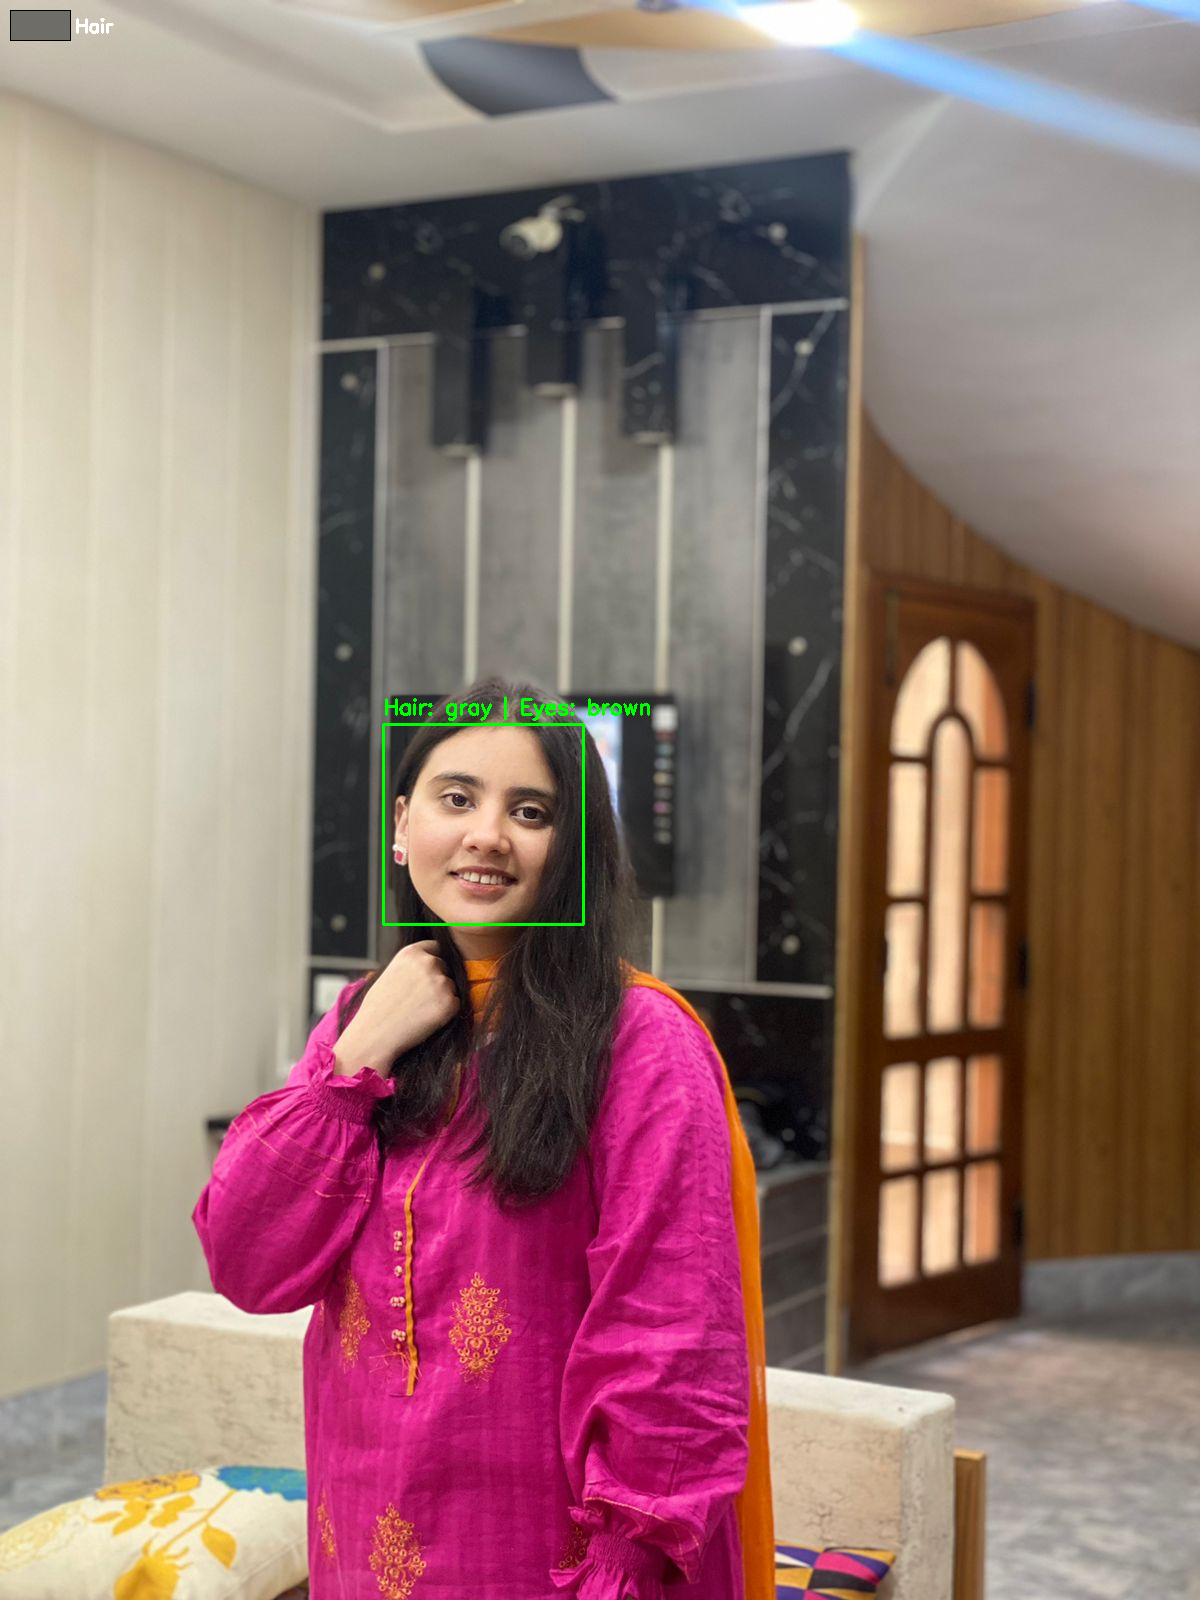

In [ ]:
# color_detection.py
# Hair & Eye color detection without training — OpenCV + K-means
# Works in Colab or local Python. No command-line args required.

import cv2
import numpy as np

# ---------- Utility: basic color naming from HSV ----------
def hsv_to_hair_name(h, s, v):
    # Hair colors are often low/medium V, various S. Heuristic bins.
    if v < 35:
        return "black"
    if s < 35 and v > 65:
        return "gray"
    # Hue bands for warm/cool browns & blondes/reds
    if v < 60 and s < 60:
        return "dark brown"
    if 10 <= h <= 30 and v > 60:
        return "blonde"
    if 0 <= h < 15 and s > 60 and v > 40:
        return "auburn"
    if 15 <= h <= 45 and s > 40 and v > 40:
        return "light brown"
    # fallback
    return "brown"

def hsv_to_eye_name(h, s, v):
    # Ignore whites; eye colors: brown/hazel/green/blue/gray
    # Assumes HSV of iris (not sclera). Heuristic bins.
    if v < 30:
        return "dark brown"
    if s < 25 and v > 60:
        return "gray"
    # blue: low H around 90-130 in OpenCV (H in [0,179]); green: ~45-85; hazel: yellow-green
    if 90 <= h <= 130 and s > 25:
        return "blue"
    if 45 <= h <= 85 and s > 25:
        return "green"
    if 30 <= h < 50 and s > 30:
        return "hazel"
    # default to brown if saturated but not matching above
    if s > 20:
        return "brown"
    return "brown"

def cluster_dominant_color(bgr_image, k=3, mask=None):
    """Return dominant BGR color (uint8 tuple) using K-means.
       If mask is provided (uint8 0/255), only cluster masked pixels."""
    img = bgr_image.copy()
    if mask is not None:
        # Select masked pixels
        pts = img[mask > 0]
    else:
        pts = img.reshape(-1, 3)

    if pts.size < 100:  # too few pixels
        return None

    pts = np.float32(pts)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    attempts = 3
    flags = cv2.KMEANS_PP_CENTERS
    compactness, labels, centers = cv2.kmeans(pts, k, None, criteria, attempts, flags)

    # Pick the largest cluster by count
    counts = np.bincount(labels.flatten())
    idx = np.argmax(counts)
    dom = centers[idx].astype(np.uint8)
    return (int(dom[0]), int(dom[1]), int(dom[2]))  # B, G, R

# ---------- Face & eyes detection ----------
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def detect_hair_color(image_bgr, face_bbox):
    """
    Estimate hair color by sampling a band above the detected face.
    face_bbox: (x, y, w, h) from Haar face detector.
    Returns: color_name (str), dominant_bgr (tuple) or (None, None)
    """
    h_img, w_img = image_bgr.shape[:2]
    x, y, w, h = face_bbox

    # Hair band above the forehead: same width as face, height = ~0.25 * face height
    band_h = max(10, int(0.25 * h))
    band_y1 = max(0, y - band_h - 5)
    band_y2 = max(0, y - 5)
    band_x1 = max(0, x)
    band_x2 = min(w_img, x + w)

    hair_band = image_bgr[band_y1:band_y2, band_x1:band_x2]
    if hair_band.size == 0:
        return None, None

    # Remove skin-like pixels from the band (keep darker, less-skin tones)
    hsv = cv2.cvtColor(hair_band, cv2.COLOR_BGR2HSV)
    # Simple skin range in HSV (broad, will vary by lighting)
    lower_skin = np.array([0, 30, 50])
    upper_skin = np.array([25, 180, 255])
    skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

    # Prefer non-skin pixels; also prefer darker pixels to bias toward hair
    v = hsv[:, :, 2]
    dark_mask = cv2.inRange(v, 0, 120)  # lower brightness likely hair
    non_skin_mask = cv2.bitwise_not(skin_mask)
    hair_mask = cv2.bitwise_and(non_skin_mask, dark_mask)

    dom_bgr = cluster_dominant_color(hair_band, k=3, mask=hair_mask)
    if dom_bgr is None:
        # Fallback: cluster whole band
        dom_bgr = cluster_dominant_color(hair_band, k=3)

    if dom_bgr is None:
        return None, None

    # Name it
    dom_hsv = cv2.cvtColor(np.uint8([[dom_bgr]]), cv2.COLOR_BGR2HSV)[0, 0]
    h, s, v = int(dom_hsv[0]), int(dom_hsv[1]), int(dom_hsv[2])
    hair_name = hsv_to_hair_name(h, s, v)
    return hair_name, dom_bgr

def detect_eye_color(image_bgr, face_bbox):
    """
    Detect eyes inside the face, estimate iris color by K-means on eye ROI
    while ignoring sclera (whites) via masks.
    Returns: color_name (str) averaged over both eyes, plus per-eye names.
    """
    x, y, w, h = face_bbox
    face_roi = image_bgr[y:y+h, x:x+w]
    gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(20, 20))
    if len(eyes) == 0:
        return None, []

    eye_names = []
    for (ex, ey, ew, eh) in eyes[:2]:  # up to two eyes
        eye_roi = face_roi[ey:ey+eh, ex:ex+ew]
        if eye_roi.size == 0:
            continue

        hsv = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2HSV)
        hch, sch, vch = cv2.split(hsv)

        # Mask to ignore sclera:
        # - very bright pixels (high V) with very low S are likely sclera
        sclera_like = cv2.inRange(sch, 0, 40)
        very_bright = cv2.inRange(vch, 180, 255)
        sclera_mask = cv2.bitwise_and(sclera_like, very_bright)
        iris_mask = cv2.bitwise_not(sclera_mask)

        # Slight erosion to reduce eyelid/skin edges
        iris_mask = cv2.erode(iris_mask, np.ones((3, 3), np.uint8), iterations=1)

        dom_bgr = cluster_dominant_color(eye_roi, k=3, mask=iris_mask)
        if dom_bgr is None:
            dom_bgr = cluster_dominant_color(eye_roi, k=2)

        if dom_bgr is None:
            continue

        dom_hsv = cv2.cvtColor(np.uint8([[dom_bgr]]), cv2.COLOR_BGR2HSV)[0, 0]
        h0, s0, v0 = int(dom_hsv[0]), int(dom_hsv[1]), int(dom_hsv[2])
        eye_names.append(hsv_to_eye_name(h0, s0, v0))

    if not eye_names:
        return None, []

    # Majority / first estimate as overall
    # Simple vote
    vals, counts = np.unique(np.array(eye_names), return_counts=True)
    overall = vals[np.argmax(counts)]
    return overall, eye_names

def analyze_image(image_bgr):
    """
    Full pipeline: detect face, hair color, eye color; return annotations and labels.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))

    results = []
    for (x, y, w, h) in faces[:1]:  # first face
        hair_name, hair_bgr = detect_hair_color(image_bgr, (x, y, w, h))
        eye_name, per_eye = detect_eye_color(image_bgr, (x, y, w, h))

        # Draw for visualization
        out = image_bgr.copy()
        cv2.rectangle(out, (x, y), (x+w, y+h), (0, 255, 0), 2)

        label_lines = []
        if hair_name:
            label_lines.append(f"Hair: {hair_name}")
        if eye_name:
            label_lines.append(f"Eyes: {eye_name}")
        label = " | ".join(label_lines) if label_lines else "No estimate"

        cv2.putText(out, label, (x, max(0, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Add small color swatch for hair
        if hair_bgr is not None:
            sw = np.full((30, 60, 3), hair_bgr, dtype=np.uint8)
            out[10:40, 10:70] = sw
            cv2.rectangle(out, (10, 10), (70, 40), (0, 0, 0), 1)
            cv2.putText(out, "Hair", (75, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        results.append({
            "face_bbox": (int(x), int(y), int(w), int(h)),
            "hair_color": hair_name,
            "eye_color": eye_name,
            "per_eye": per_eye,
            "annotated": out
        })
    return results

# --------- Demo helpers (Colab-friendly) ----------
def show_image(img_bgr, winname="image"):
    # Use cv2.imshow locally; use matplotlib/Colab otherwise
    try:
        from google.colab.patches import cv2_imshow
        cv2_imshow(img_bgr)
    except Exception:
        import matplotlib.pyplot as plt
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(rgb)
        plt.axis('off')
        plt.show()

if __name__ == "__main__":
    # Option A: Local path
    # path = "your_image.jpg"
    # img = cv2.imread(path)

    # Option B: Colab upload
    img = None
    try:
        from google.colab import files
        up = files.upload()
        if len(up):
            path = list(up.keys())[0]
            img = cv2.imread(path)
    except Exception:
        pass

    if img is None:
        print("Please set a valid image path or upload a file in Colab.")
        raise SystemExit

    results = analyze_image(img)
    if not results:
        print("No face detected.")
    else:
        res = results[0]
        print("Hair color:", res["hair_color"])
        print("Eye color:", res["eye_color"], "| per-eye:", res["per_eye"])
        show_image(res["annotated"])


# skin undertone

Saving 4.jpg to 4 (2).jpg
Average RGB: (202, 154, 130)
Detected Undertone: Warm


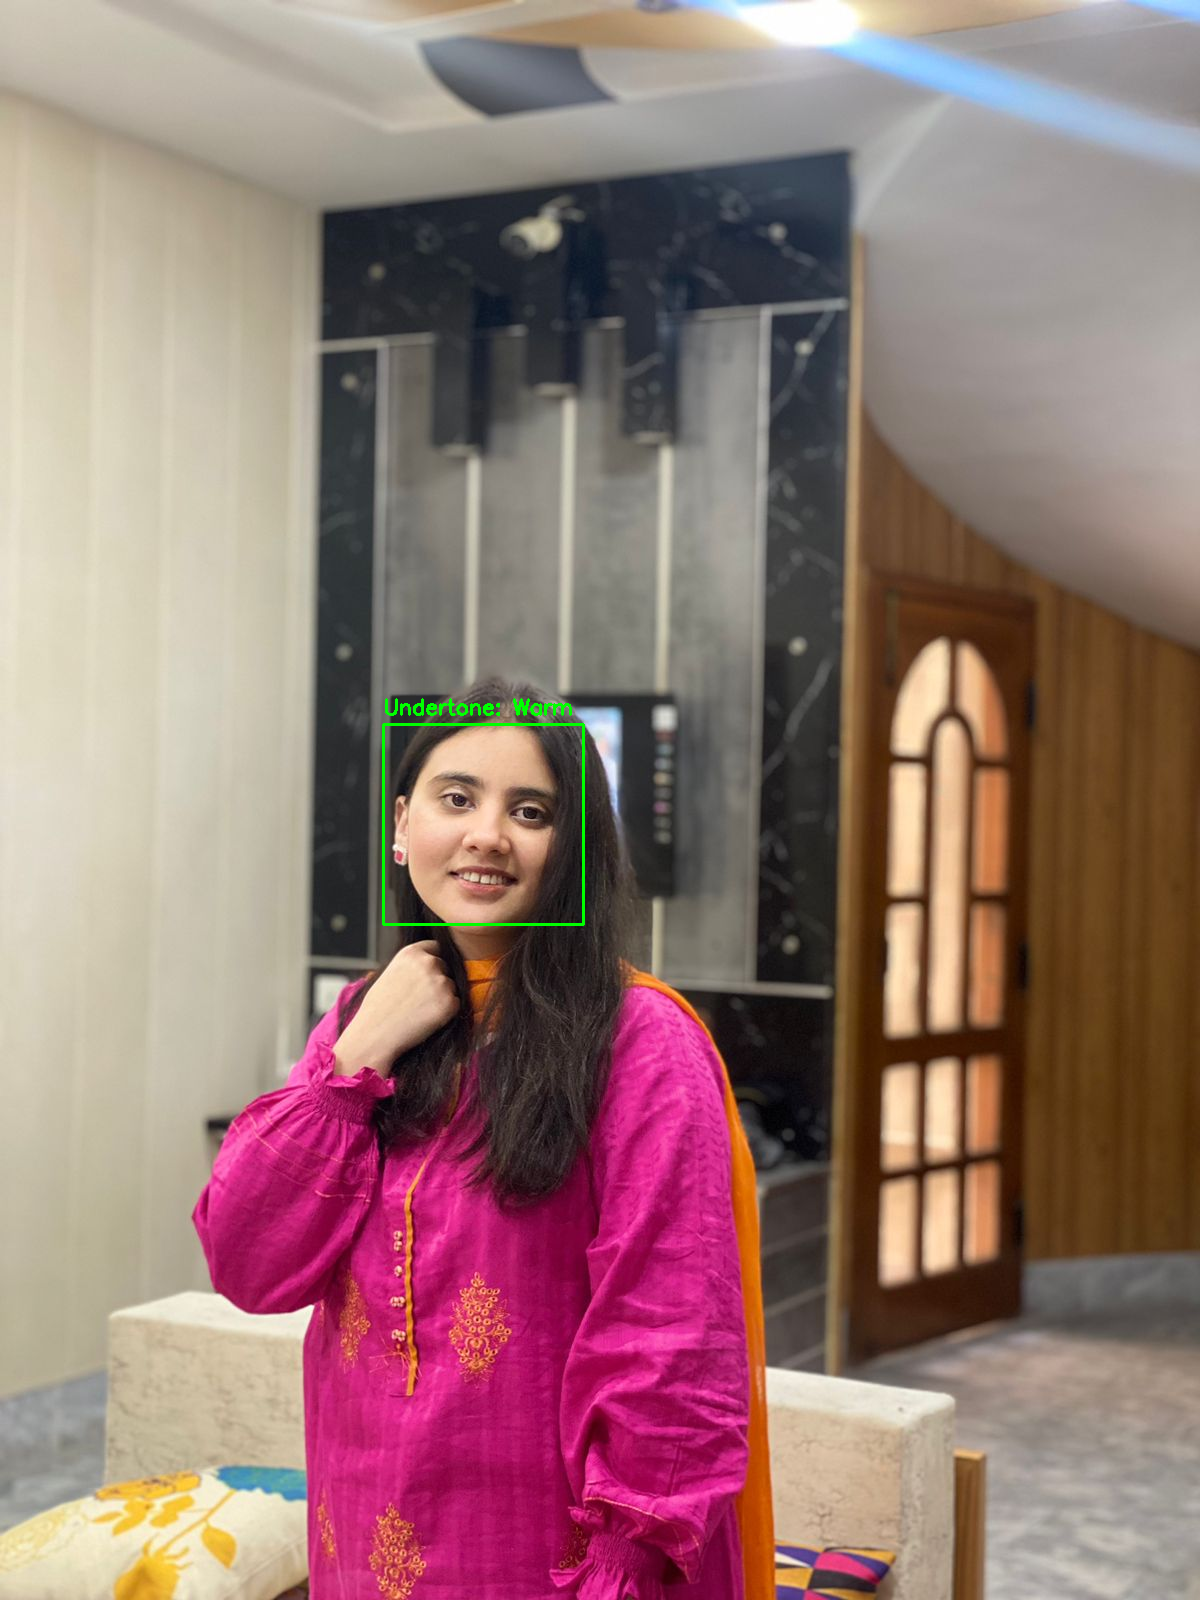

In [ ]:
# undertone_analysis.py
# Simple skin undertone analysis using average RGB from face region

import cv2
import numpy as np

def calculate_undertone(rgb_values):
    """Classify undertone based on relative RGB channel strength."""
    r, g, b = rgb_values

    if r > g and r > b:
        return "Warm"
    elif b > r and b > g:
        return "Cool"
    else:
        return "Neutral"

def extract_face_region(image_path):
    """Detect face and return a cropped central region for undertone analysis."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read image file.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) == 0:
        raise ValueError("No face detected.")

    x, y, w, h = faces[0]

    # Crop the central skin area (cheek/nose region)
    cx, cy = x + w // 4, y + int(h * 0.4)
    cw, ch = w // 2, int(h * 0.3)
    face_center = img[cy:cy+ch, cx:cx+cw]

    return face_center, img, (x, y, w, h)

def analyze_undertone(image_path):
    """Main function: detect face, crop region, compute undertone."""
    face_patch, img, bbox = extract_face_region(image_path)

    # Compute mean RGB in the patch
    rgb_mean = cv2.mean(face_patch)[:3]  # (B, G, R)
    b, g, r = rgb_mean
    rgb_tuple = (int(r), int(g), int(b))

    undertone = calculate_undertone(rgb_tuple)

    # Annotate image
    x, y, w, h = bbox
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, f"Undertone: {undertone}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    print(f"Average RGB: {rgb_tuple}")
    print(f"Detected Undertone: {undertone}")

    # Show image (works in Colab or local)
    try:
        from google.colab.patches import cv2_imshow
        cv2_imshow(img)
    except Exception:
        import matplotlib.pyplot as plt
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb)
        plt.axis('off')
        plt.show()

# ---------- Run manually ----------
if __name__ == "__main__":
    # Option 1: Manual path
    # image_path = "your_photo.jpg"

    # Option 2: Colab upload
    try:
        from google.colab import files
        up = files.upload()
        if len(up):
            image_path = list(up.keys())[0]
    except Exception:
        raise SystemExit("Please set image_path manually if not using Colab upload.")

    analyze_undertone(image_path)


Saving 4.jpg to 4 (3).jpg
Analyzing image: 4 (3).jpg
✓ Face detected successfully
✓ Skin color extracted: RGB(np.int64(200), np.int64(151), np.int64(123))
✓ Skin tone classified: Medium (Type IV)
Average RGB: (202, 154, 130)
Detected Undertone: Warm
🧍 Skin Tone: Medium
💫 Undertone: Warm
💇 Hair Color: gray
👁 Eye Color: brown

🎨 Recommended Colors:
✅ Best: mustard, terracotta, olive green, camel, bronze
🚫 Avoid: icy blue, pure white


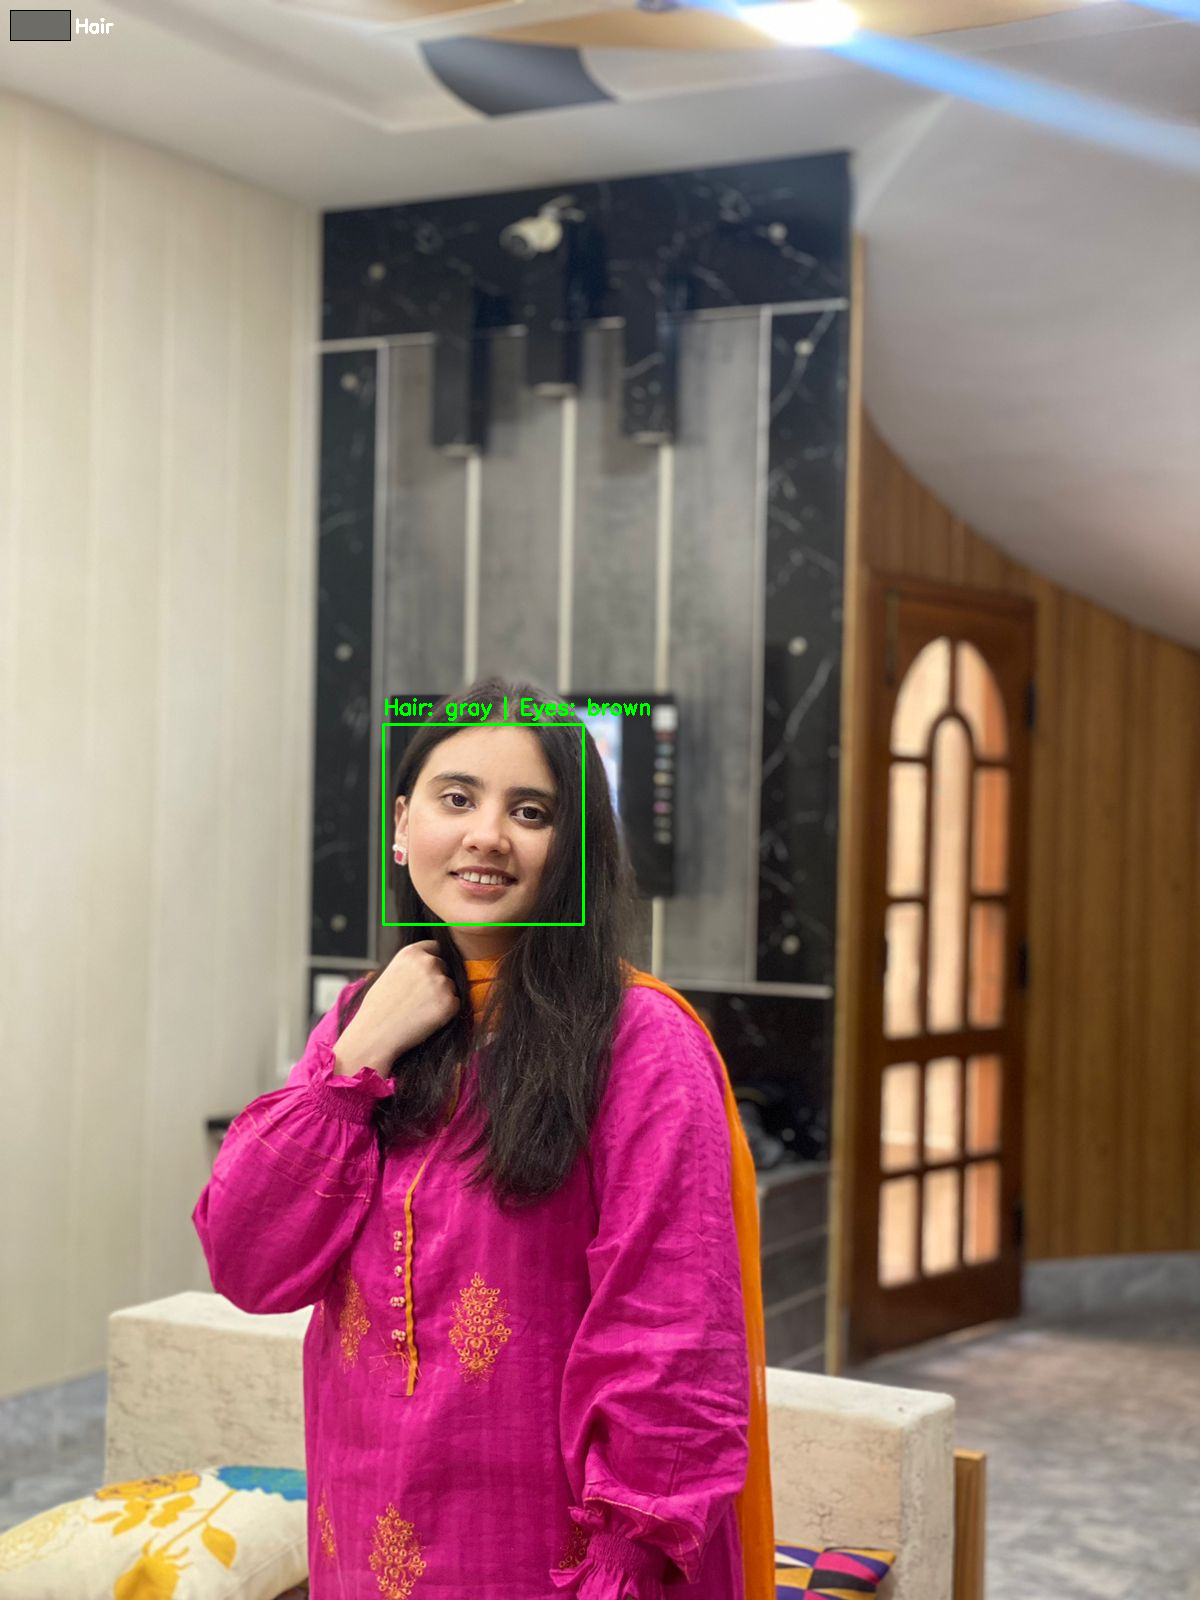

In [ ]:
# Unified Analysis Pipeline

import cv2
import numpy as np
from PIL import Image
import math

# --- Start of color_detection code ---
# color_detection.py
# Hair & Eye color detection without training — OpenCV + K-means
# Works in Colab or local Python. No command-line args required.

# ---------- Utility: basic color naming from HSV ----------
def hsv_to_hair_name(h, s, v):
    # Hair colors are often low/medium V, various S. Heuristic bins.
    if v < 35:
        return "black"
    if s < 35 and v > 65:
        return "gray"
    # Hue bands for warm/cool browns & blondes/reds
    if v < 60 and s < 60:
        return "dark brown"
    if 10 <= h <= 30 and v > 60:
        return "blonde"
    if 0 <= h < 15 and s > 60 and v > 40:
        return "auburn"
    if 15 <= h <= 45 and s > 40 and v > 40:
        return "light brown"
    # fallback
    return "brown"

def hsv_to_eye_name(h, s, v):
    # Ignore whites; eye colors: brown/hazel/green/blue/gray
    # Assumes HSV of iris (not sclera). Heuristic bins.
    if v < 30:
        return "dark brown"
    if s < 25 and v > 60:
        return "gray"
    # blue: low H around 90-130 in OpenCV (H in [0,179]); green: ~45-85; hazel: yellow-green
    if 90 <= h <= 130 and s > 25:
        return "blue"
    if 45 <= h <= 85 and s > 25:
        return "green"
    if 30 <= h < 50 and s > 30:
        return "hazel"
    # default to brown if saturated but not matching above
    if s > 20:
        return "brown"
    return "brown"

def cluster_dominant_color(bgr_image, k=3, mask=None):
    """Return dominant BGR color (uint8 tuple) using K-means.
       If mask is provided (uint8 0/255), only cluster masked pixels."""
    img = bgr_image.copy()
    if mask is not None:
        # Select masked pixels
        pts = img[mask > 0]
    else:
        pts = img.reshape(-1, 3)

    if pts.size < 100:  # too few pixels
        return None

    pts = np.float32(pts)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    attempts = 3
    flags = cv2.KMEANS_PP_CENTERS
    compactness, labels, centers = cv2.kmeans(pts, k, None, criteria, attempts, flags)

    # Pick the largest cluster by count
    counts = np.bincount(labels.flatten())
    idx = np.argmax(counts)
    dom = centers[idx].astype(np.uint8)
    return (int(dom[0]), int(dom[1]), int(dom[2]))  # B, G, R

# ---------- Face & eyes detection ----------
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def detect_hair_color(image_bgr, face_bbox):
    """
    Estimate hair color by sampling a band above the detected face.
    face_bbox: (x, y, w, h) from Haar face detector.
    Returns: color_name (str), dominant_bgr (tuple) or (None, None)
    """
    h_img, w_img = image_bgr.shape[:2]
    x, y, w, h = face_bbox

    # Hair band above the forehead: same width as face, height = ~0.25 * face height
    band_h = max(10, int(0.25 * h))
    band_y1 = max(0, y - band_h - 5)
    band_y2 = max(0, y - 5)
    band_x1 = max(0, x)
    band_x2 = min(w_img, x + w)

    hair_band = image_bgr[band_y1:band_y2, band_x1:band_x2]
    if hair_band.size == 0:
        return None, None

    # Remove skin-like pixels from the band (keep darker, less-skin tones)
    hsv = cv2.cvtColor(hair_band, cv2.COLOR_BGR2HSV)
    # Simple skin range in HSV (broad, will vary by lighting)
    lower_skin = np.array([0, 30, 50])
    upper_skin = np.array([25, 180, 255])
    skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

    # Prefer non-skin pixels; also prefer darker pixels to bias toward hair
    v = hsv[:, :, 2]
    dark_mask = cv2.inRange(v, 0, 120)  # lower brightness likely hair
    non_skin_mask = cv2.bitwise_not(skin_mask)
    hair_mask = cv2.bitwise_and(non_skin_mask, dark_mask)

    dom_bgr = cluster_dominant_color(hair_band, k=3, mask=hair_mask)
    if dom_bgr is None:
        # Fallback: cluster whole band
        dom_bgr = cluster_dominant_color(hair_band, k=3)

    if dom_bgr is None:
        return None, None

    # Name it
    dom_hsv = cv2.cvtColor(np.uint8([[dom_bgr]]), cv2.COLOR_BGR2HSV)[0, 0]
    h, s, v = int(dom_hsv[0]), int(dom_hsv[1]), int(dom_hsv[2])
    hair_name = hsv_to_hair_name(h, s, v)
    return hair_name, dom_bgr

def detect_eye_color(image_bgr, face_bbox):
    """
    Detect eyes inside the face, estimate iris color by K-means on eye ROI
    while ignoring sclera (whites) via masks.
    Returns: color_name (str) averaged over both eyes, plus per-eye names.
    """
    x, y, w, h = face_bbox
    face_roi = image_bgr[y:y+h, x:x+w]
    gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(20, 20))
    if len(eyes) == 0:
        return None, []

    eye_names = []
    for (ex, ey, ew, eh) in eyes[:2]:  # up to two eyes
        eye_roi = face_roi[ey:ey+eh, ex:ex+ew]
        if eye_roi.size == 0:
            continue

        hsv = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2HSV)
        hch, sch, vch = cv2.split(hsv)

        # Mask to ignore sclera:
        # - very bright pixels (high V) with very low S are likely sclera
        sclera_like = cv2.inRange(sch, 0, 40)
        very_bright = cv2.inRange(vch, 180, 255)
        sclera_mask = cv2.bitwise_and(sclera_like, very_bright)
        iris_mask = cv2.bitwise_not(sclera_mask)

        # Slight erosion to reduce eyelid/skin edges
        iris_mask = cv2.erode(iris_mask, np.ones((3, 3), np.uint8), iterations=1)

        dom_bgr = cluster_dominant_color(eye_roi, k=3, mask=iris_mask)
        if dom_bgr is None:
            dom_bgr = cluster_dominant_color(eye_roi, k=2)

        if dom_bgr is None:
            continue

        dom_hsv = cv2.cvtColor(np.uint8([[dom_bgr]]), cv2.COLOR_BGR2HSV)[0, 0]
        h0, s0, v0 = int(dom_hsv[0]), int(dom_hsv[1]), int(dom_hsv[2])
        eye_names.append(hsv_to_eye_name(h0, s0, v0))

    if not eye_names:
        return None, []

    # Majority / first estimate as overall
    # Simple vote
    vals, counts = np.unique(np.array(eye_names), return_counts=True)
    overall = vals[np.argmax(counts)]
    return overall, eye_names

def analyze_image_color_detection(image_bgr):
    """
    Full pipeline: detect face, hair color, eye color; return annotations and labels.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))

    results = []
    for (x, y, w, h) in faces[:1]:  # first face
        hair_name, hair_bgr = detect_hair_color(image_bgr, (x, y, w, h))
        eye_name, per_eye = detect_eye_color(image_bgr, (x, y, w, h))

        # Draw for visualization
        out = image_bgr.copy()
        cv2.rectangle(out, (x, y), (x+w, y+h), (0, 255, 0), 2)

        label_lines = []
        if hair_name:
            label_lines.append(f"Hair: {hair_name}")
        if eye_name:
            label_lines.append(f"Eyes: {eye_name}")
        label = " | ".join(label_lines) if label_lines else "No estimate"

        cv2.putText(out, label, (x, max(0, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Add small color swatch for hair
        if hair_bgr is not None:
            sw = np.full((30, 60, 3), hair_bgr, dtype=np.uint8)
            out[10:40, 10:70] = sw
            cv2.rectangle(out, (10, 10), (70, 40), (0, 0, 0), 1)
            cv2.putText(out, "Hair", (75, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        results.append({
            "face_bbox": (int(x), int(y), int(w), int(h)),
            "hair_color": hair_name,
            "eye_color": eye_name,
            "per_eye": per_eye,
            "annotated": out
        })
    return results
# --- End of color_detection code ---

# --- Start of undertone_analysis code ---
# undertone_analysis.py
# Simple skin undertone analysis using average RGB from face region

def calculate_undertone(rgb_values):
    """Classify undertone based on relative RGB channel strength."""
    r, g, b = rgb_values

    if r > g and r > b:
        return "Warm"
    elif b > r and b > g:
        return "Cool"
    else:
        return "Neutral"

def extract_face_region_undertone(image_path):
    """Detect face and return a cropped central region for undertone analysis."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read image file.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) == 0:
        raise ValueError("No face detected.")

    x, y, w, h = faces[0]

    # Crop the central skin area (cheek/nose region)
    cx, cy = x + w // 4, y + int(h * 0.4)
    cw, ch = w // 2, int(h * 0.3)
    face_center = img[cy:cy+ch, cx:cx+cw]

    return face_center, img, (x, y, w, h)

def analyze_undertone_analysis(image_path):
    """Main function: detect face, crop region, compute undertone."""
    face_patch, img, bbox = extract_face_region_undertone(image_path)

    # Compute mean RGB in the patch
    rgb_mean = cv2.mean(face_patch)[:3]  # (B, G, R)
    b, g, r = rgb_mean
    rgb_tuple = (int(r), int(g), int(b))

    undertone = calculate_undertone(rgb_tuple)

    # Annotate image
    # x, y, w, h = bbox # Already done in extract_face_region_undertone
    # cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2) # Already done in extract_face_region_undertone
    # cv2.putText(img, f"Undertone: {undertone}", (x, y-10), # Already done in extract_face_region_undertone
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    print(f"Average RGB: {rgb_tuple}")
    print(f"Detected Undertone: {undertone}")

    return undertone
# --- End of undertone_analysis code ---


# --- Start of color_recommendations code ---
# color_recommendations.py
# Suggest clothing / makeup / palette colors based on detected features

COLOR_PALETTES = {
    "Light_Warm": {
        "best_colors": ["peach", "coral", "warm beige", "gold", "olive"],
        "avoid_colors": ["pure white", "black", "cool greys"]
    },
    "Light_Cool": {
        "best_colors": ["soft pink", "lavender", "silver", "navy", "emerald"],
        "avoid_colors": ["orange", "warm browns"]
    },
    "Medium_Warm": {
        "best_colors": ["mustard", "terracotta", "olive green", "camel", "bronze"],
        "avoid_colors": ["icy blue", "pure white"]
    },
    "Medium_Cool": {
        "best_colors": ["rose", "plum", "teal", "charcoal", "burgundy"],
        "avoid_colors": ["orange", "beige"]
    },
    "Deep_Warm": {
        "best_colors": ["rust", "maroon", "olive", "golden brown", "burnt orange"],
        "avoid_colors": ["icy pastels", "silver"]
    },
    "Deep_Cool": {
        "best_colors": ["navy", "royal blue", "deep purple", "emerald", "fuchsia"],
        "avoid_colors": ["mustard", "orange", "tan"]
    },
    "Fair_Neutral": {
        "best_colors": ["rose gold", "soft beige", "mint", "sky blue"],
        "avoid_colors": ["harsh red", "black"]
    },
}

# Default fallback palette
default_palette = {
    "best_colors": ["beige", "teal", "soft grey", "rose", "navy"],
    "avoid_colors": ["pure black", "fluorescent orange"]
}

def get_color_recommendations(skin_tone, undertone, hair_color=None, eye_color=None):
    """
    Return the best and avoid color lists based on tone + undertone combo.
    hair_color and eye_color can later be used to fine-tune palette suggestions.
    """
    key = f"{skin_tone}_{undertone}"
    palette = COLOR_PALETTES.get(key, default_palette)
    return palette
# --- End of color_recommendations code ---


# --- Start of skin tone analysis (from original code) ---
# Step 1: Face Detection
face_cascade_skin = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_face_skin(image_path):
    img = cv2.imread(image_path)
    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade_skin.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        face_region = img[y:y+h, x:x+w]
        return face_region
    return None


# Step 2: Extract Skin Tone from Face
def get_dominant_color(face_region):
    """Extract dominant skin color from face region"""
    # Convert to RGB
    face_rgb = cv2.cvtColor(face_region, cv2.COLOR_BGR2RGB)

    # Focus on center of face (avoid hair, background)
    h, w = face_rgb.shape[:2]
    center_face = face_rgb[int(h*0.3):int(h*0.7), int(w*0.25):int(w*0.75)]

    # Resize for faster processing
    face_small = cv2.resize(center_face, (50, 50))

    # Reshape to list of pixels
    pixels = face_small.reshape(-1, 3)

    # Remove outliers (very dark/bright pixels - removes shadows, highlights)
    pixels = pixels[(pixels.sum(axis=1) > 50) & (pixels.sum(axis=1) < 650)]

    # Calculate median color (more robust than mean)
    if len(pixels) > 0:
        skin_tone = np.median(pixels, axis=0)
    else:
        skin_tone = np.array([120, 120, 120])  # fallback

    return skin_tone.astype(int)


# Step 3: Classify Skin Tone (includes "Black" category)
def classify_skin_tone(rgb_color):
    """
    Classify skin tone into categories (now includes Black tone)
    Based on brightness thresholds. You may tune these if needed.
    """
    R, G, B = rgb_color

    # Perceived brightness (slightly better than simple mean)
    brightness = 0.299*R + 0.587*G + 0.114*B

    if brightness > 200:
        category = "Very Fair"
        fitzpatrick = "Type I-II"
    elif brightness > 170:
        category = "Fair"
        fitzpatrick = "Type III"
    elif brightness > 140:
        category = "Medium"
        fitzpatrick = "Type IV"
    elif brightness > 110:
        category = "Tan/Olive"
        fitzpatrick = "Type V"
    elif brightness > 70:
        category = "Deep/Dark"
        fitzpatrick = "Type VI"
    else:
        category = "Black"
        fitzpatrick = "Type VI+"

    return category, fitzpatrick, brightness

def analyze_skin_tone(image_path):
    """
    Complete pipeline: Detect face -> Extract color -> Classify -> Recommend
    """
    print(f"Analyzing image: {image_path}")

    # Step 1: Detect face
    face_region = detect_face_skin(image_path)

    if face_region is None:
        return {
            "success": False,
            "error": "No face detected in the image. Please try again with a clear face photo, or check the image path."
        }

    print("✓ Face detected successfully")

    # Step 2: Extract skin tone
    skin_color_rgb = get_dominant_color(face_region)
    print(f"✓ Skin color extracted: RGB{tuple(skin_color_rgb)}")

    # Step 3: Classify skin tone
    skin_category, fitzpatrick_type, brightness = classify_skin_tone(skin_color_rgb)
    print(f"✓ Skin tone classified: {skin_category} ({fitzpatrick_type})")

    return skin_category
# --- End of skin tone analysis (from original code) ---


# --- Main Analysis Pipeline ---
# Step 1: Upload image
from google.colab import files
up = files.upload()
image_path = list(up.keys())[0]
img = cv2.imread(image_path)

# Step 2: Hair + Eye detection
# analyze_image expects BGR image, not path
face_results = analyze_image_color_detection(img)
if not face_results:
    raise ValueError("No face detected.")
result = face_results[0]
hair_color = result["hair_color"]
eye_color = result["eye_color"]

# Step 3: Skin tone prediction
# analyze_skin_tone expects image path
skin_tone = analyze_skin_tone(image_path) # Using the existing skin tone classification

# Step 4: Undertone detection
# analyze_undertone expects image path
undertone = analyze_undertone_analysis(image_path)

# Step 5: Get palette recommendation
palette = get_color_recommendations(skin_tone, undertone, hair_color, eye_color)

# Step 6: Display results
print("🧍 Skin Tone:", skin_tone)
print("💫 Undertone:", undertone)
print("💇 Hair Color:", hair_color)
print("👁 Eye Color:", eye_color)
print("\n🎨 Recommended Colors:")
print("✅ Best:", ", ".join(palette["best_colors"]))
print("🚫 Avoid:", ", ".join(palette["avoid_colors"]))

# Optional: Display annotated image from analyze_image_color_detection
show_image(result["annotated"])

In [ ]:
# Import the files module
from google.colab import files

# Download each model one by one
files.download('skin_tone_model.h5')
files.download('hair_model.h5')
files.download('eye_model.h5')
files.download('undertone_model.h5')

FileNotFoundError: Cannot find file: skin_tone_model.h5